In [35]:
pip install dcor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.7 MB/s eta 0:00:00


In [1]:
pip install pymongo pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 10.0 MB/s eta 0:00:00


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import certifi
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import dcor

## Query the data

In [18]:
def query_mongodb(uri=blured):
    client = MongoClient(uri, tls=True, tlsCAFile=certifi.where())

    db = client[db_name]
    collection = db[collection_name]

    filtro = filtro or {}

    # bring data
    docs = list(collection.find(filtro))

    if not docs:
        return pd.DataFrame()  # retorna vacío si no hay datos

    df = pd.DataFrame(docs)

    # transform _id to datetime
    if "_id" in df.columns:
        df["_id"] = pd.to_datetime(df["_id"])
        df.set_index("_id", inplace=True)

    return df

### Data

In [39]:
df= query_mongodb()
df.tail()

,Close_DXY,Close_GOLD,Close_HYG,Close_LQD,Close_OIL,Drawdown,IV_RV_Ratio,Intraday_VIX_Move,Momentum_1M,Momentum_3M,...,VIX_Percentile,VIX_RV_Spread,VIX_STD_10,VIX_STD_5,VIX_Trend,VIX_Vol_10d,VIX_Vol_21d,VIX_Vol_5d,VIX_Zscore,VIX_Zscore_Sq
_id,,,,,,,,,,,,,,,,,,,,,
2026-03-16,99.709999,4994.000000,79.449997,108.690002,93.500000,-0.040011,195.038664,-1,-0.020010,-0.003281,...,0.857143,23.389460,2.395851,1.727253,3.003997,0.126999,0.096161,0.093235,0.336495,0.113229
2026-03-17,99.580002,5001.000000,79.809998,109.300003,96.209999,-0.037616,184.735176,-1,-0.017565,-0.008660,...,0.837302,22.248909,2.506332,2.221288,2.878428,0.124841,0.097006,0.094638,-0.045627,0.002082
2026-03-18,100.089996,4889.899902,79.400002,108.709999,96.320000,-0.050712,195.009412,1,-0.031932,-0.030697,...,0.908730,24.961340,2.124812,2.187739,2.921937,0.124190,0.099903,0.112569,0.719734,0.518017
2026-03-19,99.230003,4600.700195,79.660004,109.190002,96.139999,-0.053322,190.808938,-1,-0.039937,-0.039544,...,0.873016,23.933905,2.101249,1.822026,2.890505,0.120434,0.100110,0.093360,0.342460,0.117279
2026-03-20,99.502998,4574.899902,78.919998,107.849998,98.230003,-0.067653,199.586568,1,-0.051795,-0.058368,...,0.928571,26.645823,1.632818,1.670470,3.016884,0.097292,0.102365,0.111692,1.095159,1.199373


In [20]:
df.shape

(4943, 42)

In [21]:
df.columns

Index(['Close_DXY', 'Close_GOLD', 'Close_HYG', 'Close_LQD', 'Close_OIL',
       'Drawdown', 'IV_RV_Ratio', 'Intraday_VIX_Move', 'Momentum_1M',
       'Momentum_3M', 'Momentum_6M', 'Open_MOVE', 'Open_SP500', 'Open_VIX',
       'RV_10d', 'RV_21d', 'RV_21d_Sq', 'RV_5d', 'SPX_Gap', 'SPX_VIX_Corr_21d',
       'SPX_Volume_Norm', 'VIX3M_Spread', 'VIX_Contango', 'VIX_Gap',
       'VIX_Lag1', 'VIX_Lag2', 'VIX_Lag5', 'VIX_MA_10', 'VIX_MA_20',
       'VIX_MA_5', 'VIX_MOVE_Ratio', 'VIX_MeanRev', 'VIX_Percentile',
       'VIX_RV_Spread', 'VIX_STD_10', 'VIX_STD_5', 'VIX_Trend', 'VIX_Vol_10d',
       'VIX_Vol_21d', 'VIX_Vol_5d', 'VIX_Zscore', 'VIX_Zscore_Sq'],
      dtype='object')

#EDA

In [22]:
sns.set_theme(style="whitegrid")
data_eda=df.copy()

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

## Seasonality

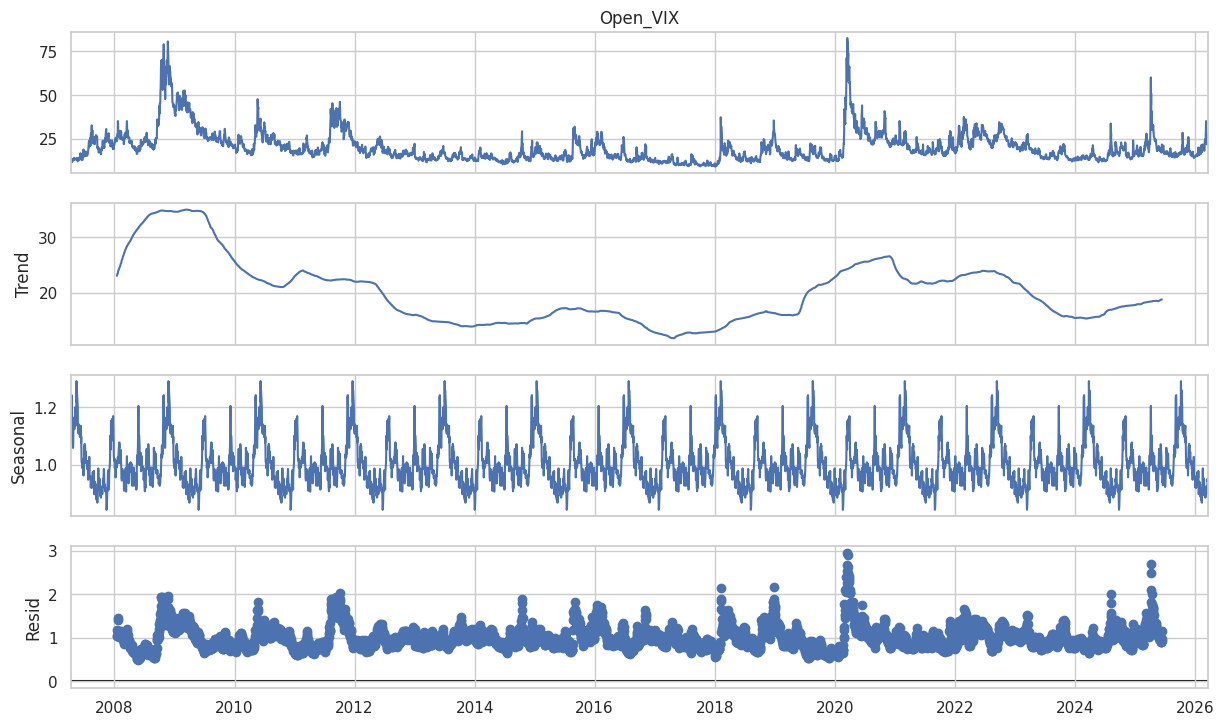

In [43]:
# @title
ts = data_eda["Open_VIX"]

# decomposition (multiplicative)
decomp = seasonal_decompose(ts, model='multiplicative', period=400)

# plot
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.show()

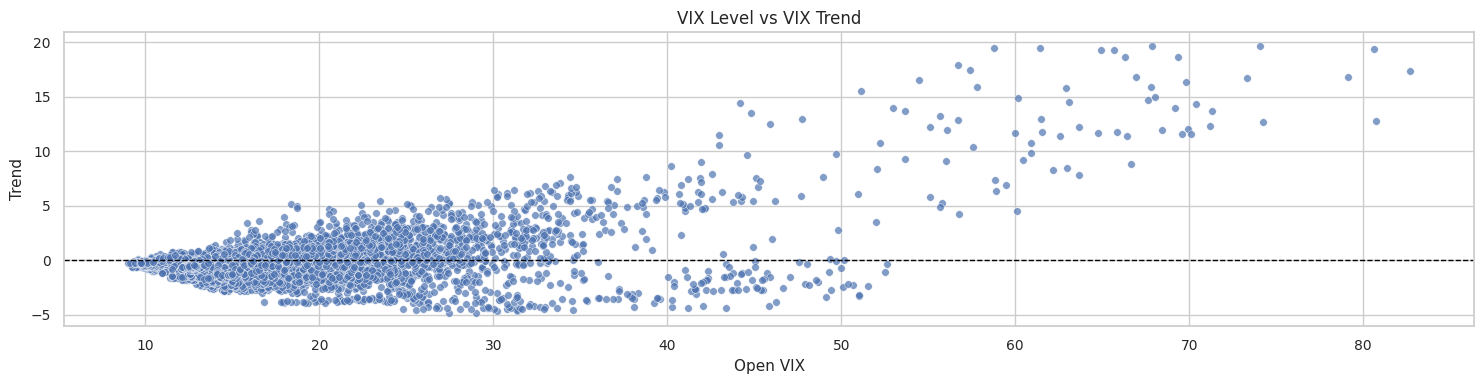

In [23]:
# @title
plt.figure(figsize=(15,4))

sns.scatterplot(
    data=data_eda,
    x="Open_VIX",
    y="VIX_Trend",
    alpha=0.7,
    s=30
)

plt.axhline(0, linestyle="--", linewidth=1, color="black")

plt.title("VIX Level vs VIX Trend")
plt.xlabel("Open VIX")
plt.ylabel("Trend")

plt.tight_layout()
plt.show()

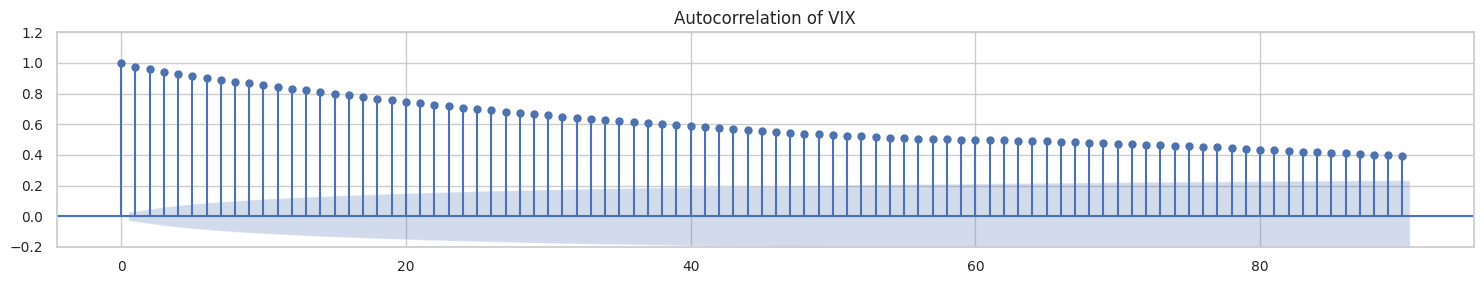

In [24]:
# @title
fig, ax = plt.subplots(figsize=(15,3))

plot_acf(data_eda["Open_VIX"], lags=90, ax=ax)

ax.set_title("Autocorrelation of VIX")
ax.set_ylim(top=1.2, bottom=-0.2)

plt.tight_layout()
plt.show()

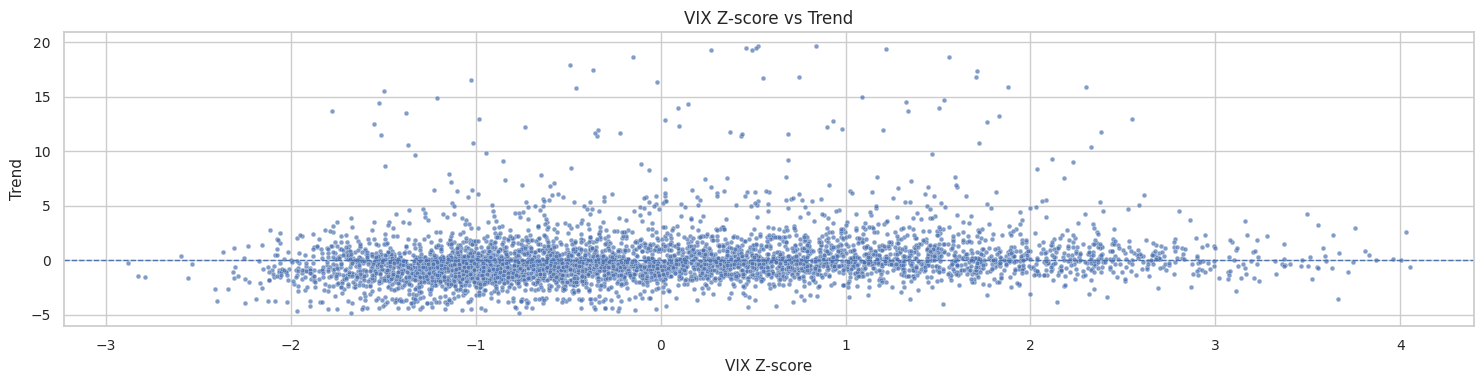

In [25]:
# @title
plt.figure(figsize=(15,4))

sns.scatterplot(
    data=df,
    x="VIX_Zscore",
    y="VIX_Trend",
    alpha=0.7,
    s=12
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("VIX Z-score vs Trend")
plt.xlabel("VIX Z-score")
plt.ylabel("Trend")

plt.tight_layout()
plt.show()

In [26]:
data_eda["VIX_5d"]=data_eda["Open_VIX"].shift(5)
data_eda["VIX_10d"]=data_eda["Open_VIX"].shift(10)
data_eda["VIX_15d"]=data_eda["Open_VIX"].shift(15)
data_eda["VIX_20d"]=data_eda["Open_VIX"].shift(20)
data_eda["VIX_40d"]=data_eda["Open_VIX"].shift(40)
data_eda["VIX_60d"]=data_eda["Open_VIX"].shift(60)

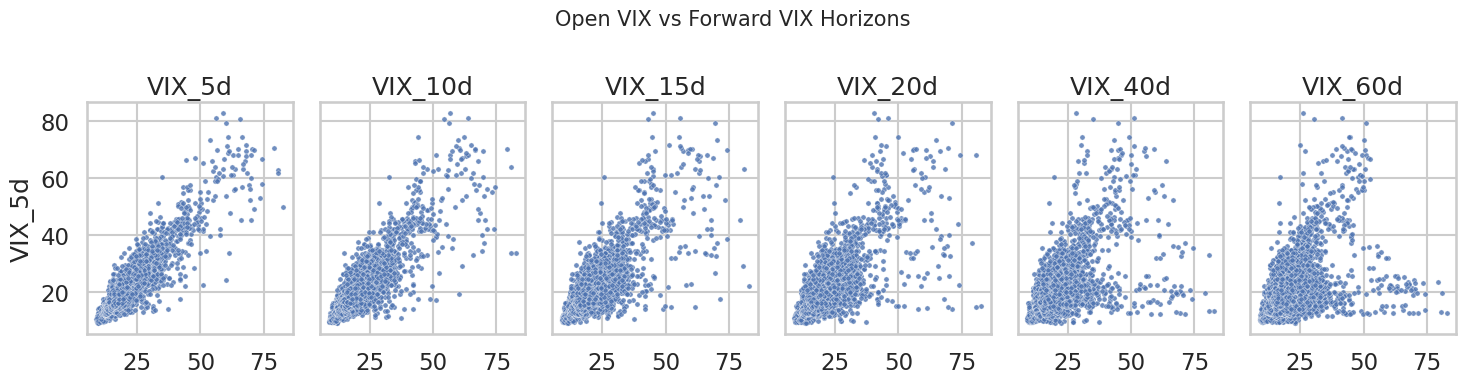

In [27]:
# @title
sns.set_theme(style="whitegrid", context="talk")

cols = ['VIX_5d', 'VIX_10d', 'VIX_15d', 'VIX_20d', 'VIX_40d','VIX_60d']

fig, axes = plt.subplots(1, len(cols), figsize=(15,4), sharey=True)

for i, col in enumerate(cols):
    sns.scatterplot(
        data=data_eda,
        x="Open_VIX",
        y=col,
        alpha=0.8,
        s=14,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")

fig.suptitle("Open VIX vs Forward VIX Horizons", fontsize=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_177/1972895582.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_trend = data_eda.groupby("VIX_regime")["VIX_fwd_5d"].mean()


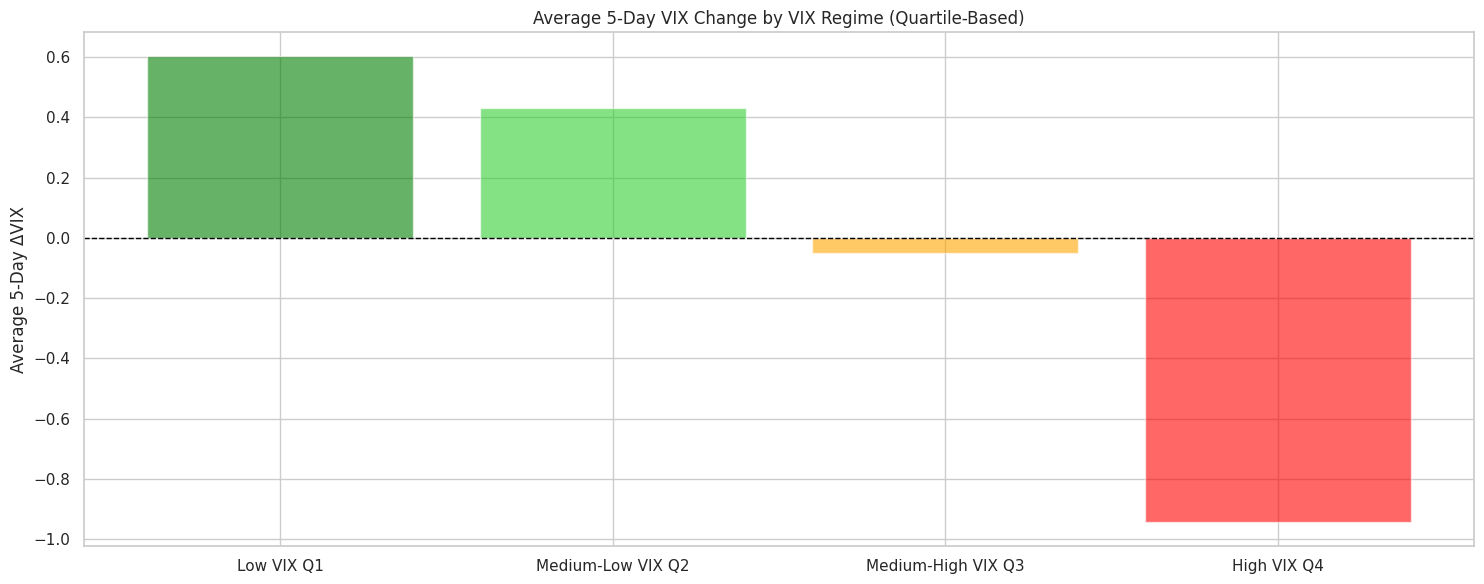

In [28]:
# @title
sns.set_theme(style="whitegrid")

# Forward 5-day VIX change
data_eda["VIX_fwd_5d"] = data_eda["Open_VIX"].shift(-5) - data_eda["Open_VIX"]

Q1 = data_eda["Open_VIX"].quantile(0.25)
Q2 = data_eda["Open_VIX"].quantile(0.50)
Q3 = data_eda["Open_VIX"].quantile(0.75)

bins = [data_eda["Open_VIX"].min()-1, Q1, Q2, Q3, data_eda["Open_VIX"].max()+1]
labels = ["Low VIX Q1", "Medium-Low VIX Q2" , "Medium-High VIX Q3", "High VIX Q4"]

data_eda["VIX_regime"] = pd.cut(data_eda["Open_VIX"], bins=bins, labels=labels)

regime_trend = data_eda.groupby("VIX_regime")["VIX_fwd_5d"].mean()

plt.figure(figsize=(15,6))

colors = {
    "Low VIX Q1":"green",
    "Medium-Low VIX Q2":"limegreen",
    "Medium-High VIX Q3":"orange",
    "High VIX Q4":"red"
}

for regime in labels:
    plt.bar(
        x=[regime],
        height=[regime_trend[regime]],
        color=colors[regime],
        alpha=0.6
    )

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Average 5-Day ΔVIX")
plt.title("Average 5-Day VIX Change by VIX Regime (Quartile-Based)")
plt.tight_layout()
plt.show()

## VIX - SP

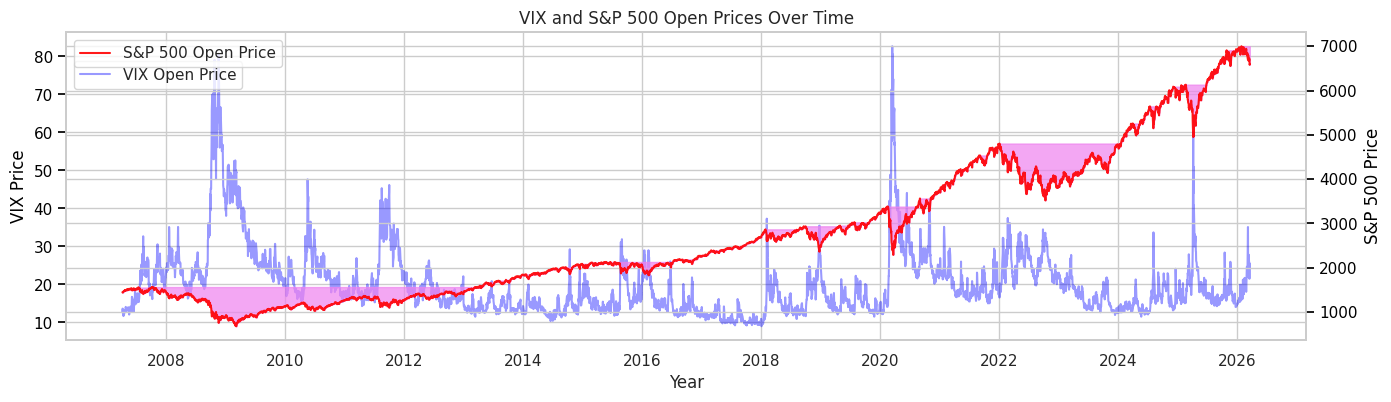

In [29]:
# @title
fig, ax1 = plt.subplots(figsize=(16,4))
data_eda["Historical_Maximum"]=data_eda["Open_SP500"].cummax()

# VIX
ax1.plot(data_eda.index, data_eda["Open_VIX"], label="VIX Open Price", color="blue", alpha=0.4)
ax1.set_xlabel("Year")
ax1.set_ylabel("VIX Price", color="black")
ax1.tick_params(axis='y', colors='black')
ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.93))

# S&P 500
ax2 = ax1.twinx()
ax2.plot(data_eda.index, data_eda["Open_SP500"], label="S&P 500 Open Price", color="red", alpha=0.9)
ax2.fill_between(
    data_eda.index,
    data_eda["Historical_Maximum"],
    data_eda["Open_SP500"],
    color="violet",
    alpha=0.7
)
ax2.set_ylabel("S&P 500 Price", color="black")
ax2.tick_params(axis='y', colors='black')
ax2.legend(loc='upper left')

plt.title("VIX and S&P 500 Open Prices Over Time")
plt.xticks(rotation=45)
plt.show()


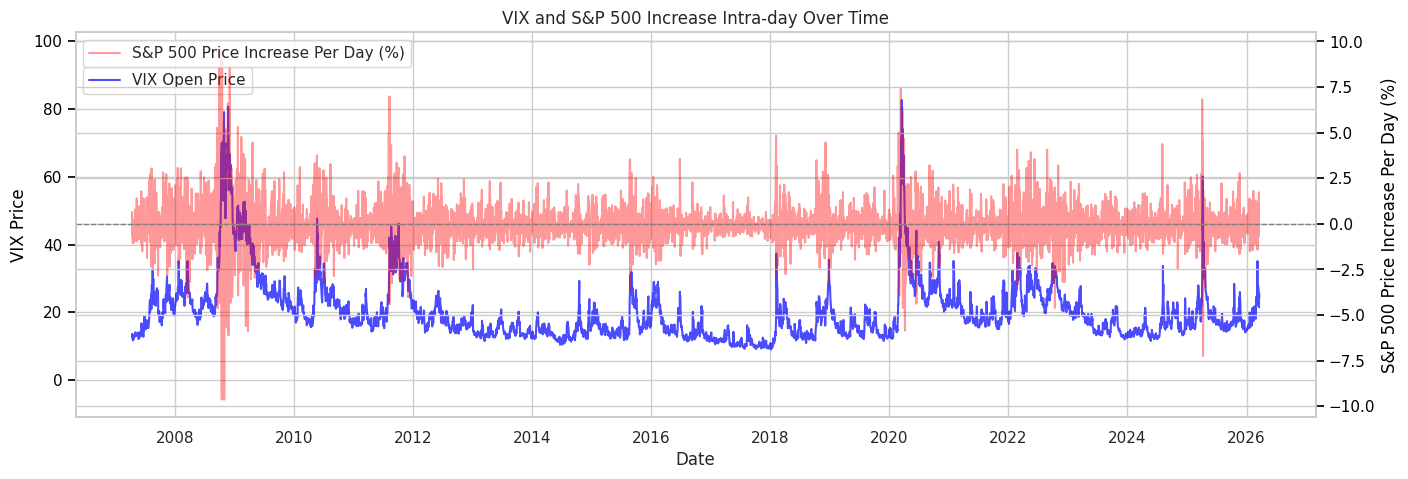

In [30]:
fig, ax1 = plt.subplots(figsize=(16,5))

# VIX
ax1.plot(data_eda.index, data_eda["Open_VIX"], label="VIX Open Price", color="blue", alpha=0.7)
ax1.set_xlabel("Date")
ax1.set_ylabel("VIX Price", color="black")
ax1.set_ylim(bottom=data_eda["Open_VIX"].min()-20, top=data_eda["Open_VIX"].max()+20)
ax1.tick_params(axis='y', colors='black')
ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.93))

# S&P 500
ax2 = ax1.twinx()
ax2.plot(data_eda.index, ((data_eda["Open_SP500"]/data_eda["Open_SP500"].shift(-1))*100-100), label="S&P 500 Price Increase Per Day (%)", color="red", alpha=0.4)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel("S&P 500 Price Increase Per Day (%)", color="black")
ax2.tick_params(axis='y', colors='black')
ax2.legend(loc='upper left')

plt.title("VIX and S&P 500 Increase Intra-day Over Time")
plt.xticks(rotation=45)
plt.show()

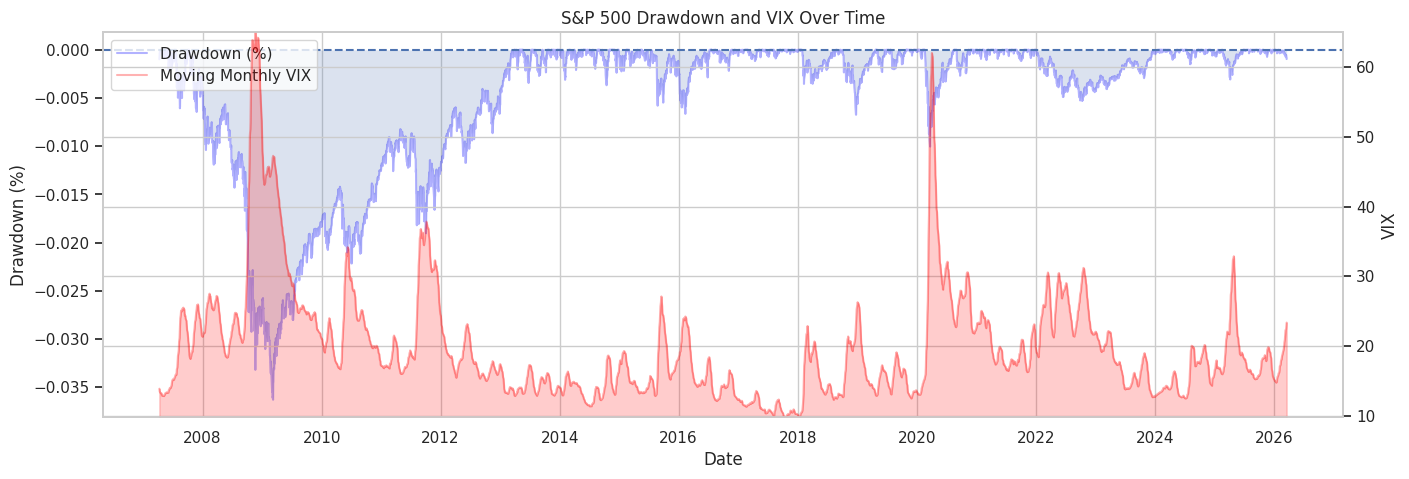

In [31]:
drawdown_pct = (data_eda["Drawdown"] / data_eda["Historical_Maximum"]) * 100

fig, ax1 = plt.subplots(figsize=(16,5))

ax1.plot(data_eda.index, drawdown_pct, label="Drawdown (%)", color="blue",alpha=0.3)

ax1.fill_between(data_eda.index,drawdown_pct,0,alpha=0.2)

ax1.axhline(0, linestyle='--', linewidth=1.5)

ax1.set_title("S&P 500 Drawdown and VIX Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Drawdown (%)")
ax1.grid(axis='y')

ax2 = ax1.twinx()

ax2.plot(data_eda.index, data_eda["VIX_MA_20"], label="Moving Monthly VIX", color="red",alpha=0.3)

ax2.fill_between( data_eda.index, data_eda["VIX_MA_20"],0,alpha=0.2,color="red")

ax2.set_ylabel("VIX")
ax2.set_ylim(data_eda["VIX_MA_20"].min(), data_eda["VIX_MA_20"].max())

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()


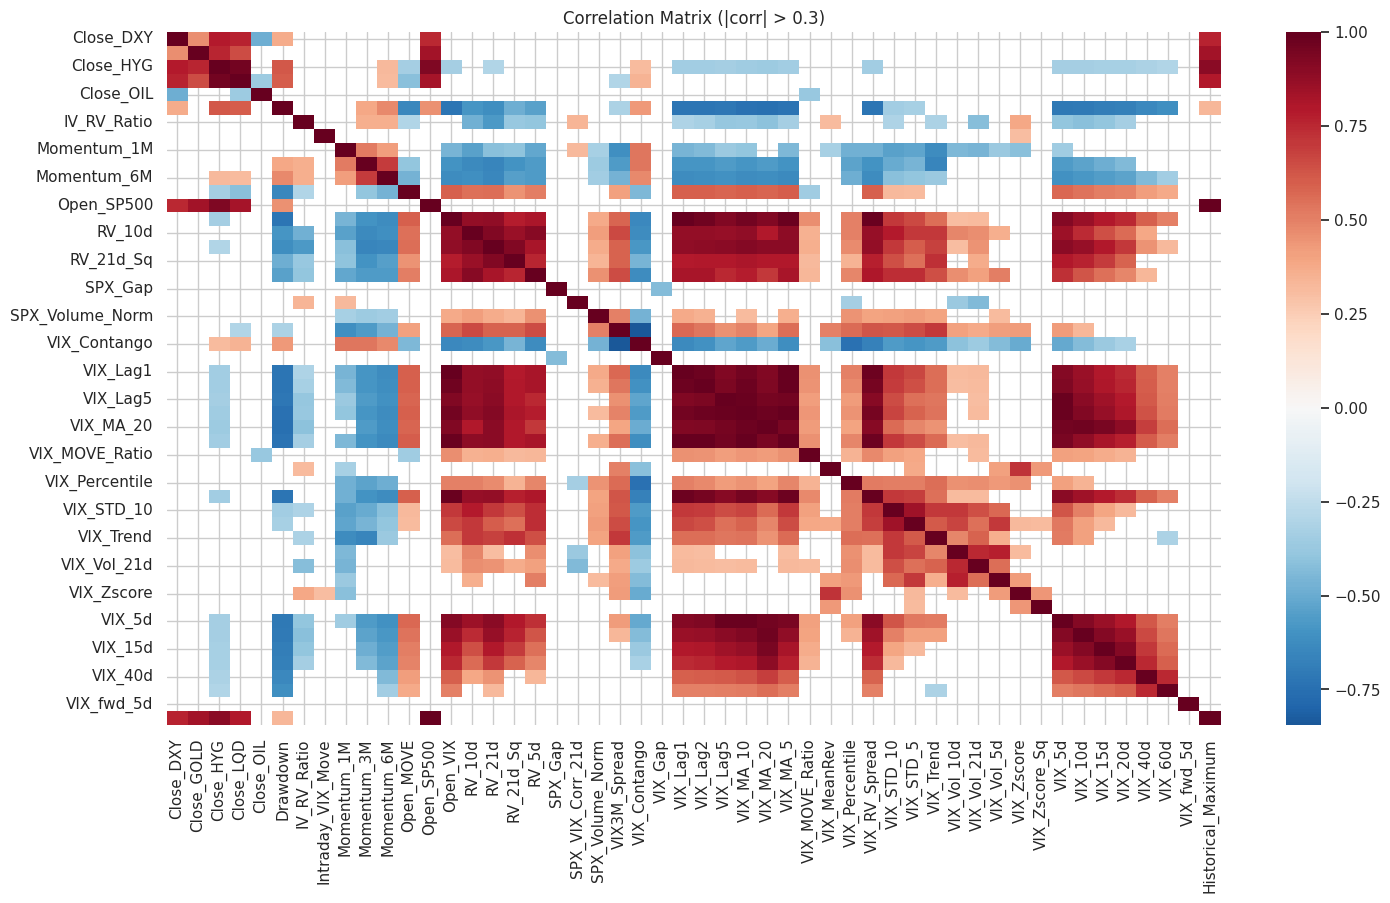

In [49]:
# just the numeric ones, pearson is not capable to be computed with categorical
numeric_df = data_eda.select_dtypes(include=['number'])

corr = numeric_df.corr()

corr_filtered = corr.where(np.abs(corr) > 0.3)
corr_filtered= corr_filtered

plt.figure(figsize=(17,9))
sns.heatmap(corr_filtered, cmap='RdBu_r', center=0)

plt.title("Correlation Matrix (|corr| > 0.3)")
plt.show()

/usr/local/lib/python3.12/dist-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(float64, 1d, C), array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(int64, 1d, C), array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(int64, 1d, C), arr

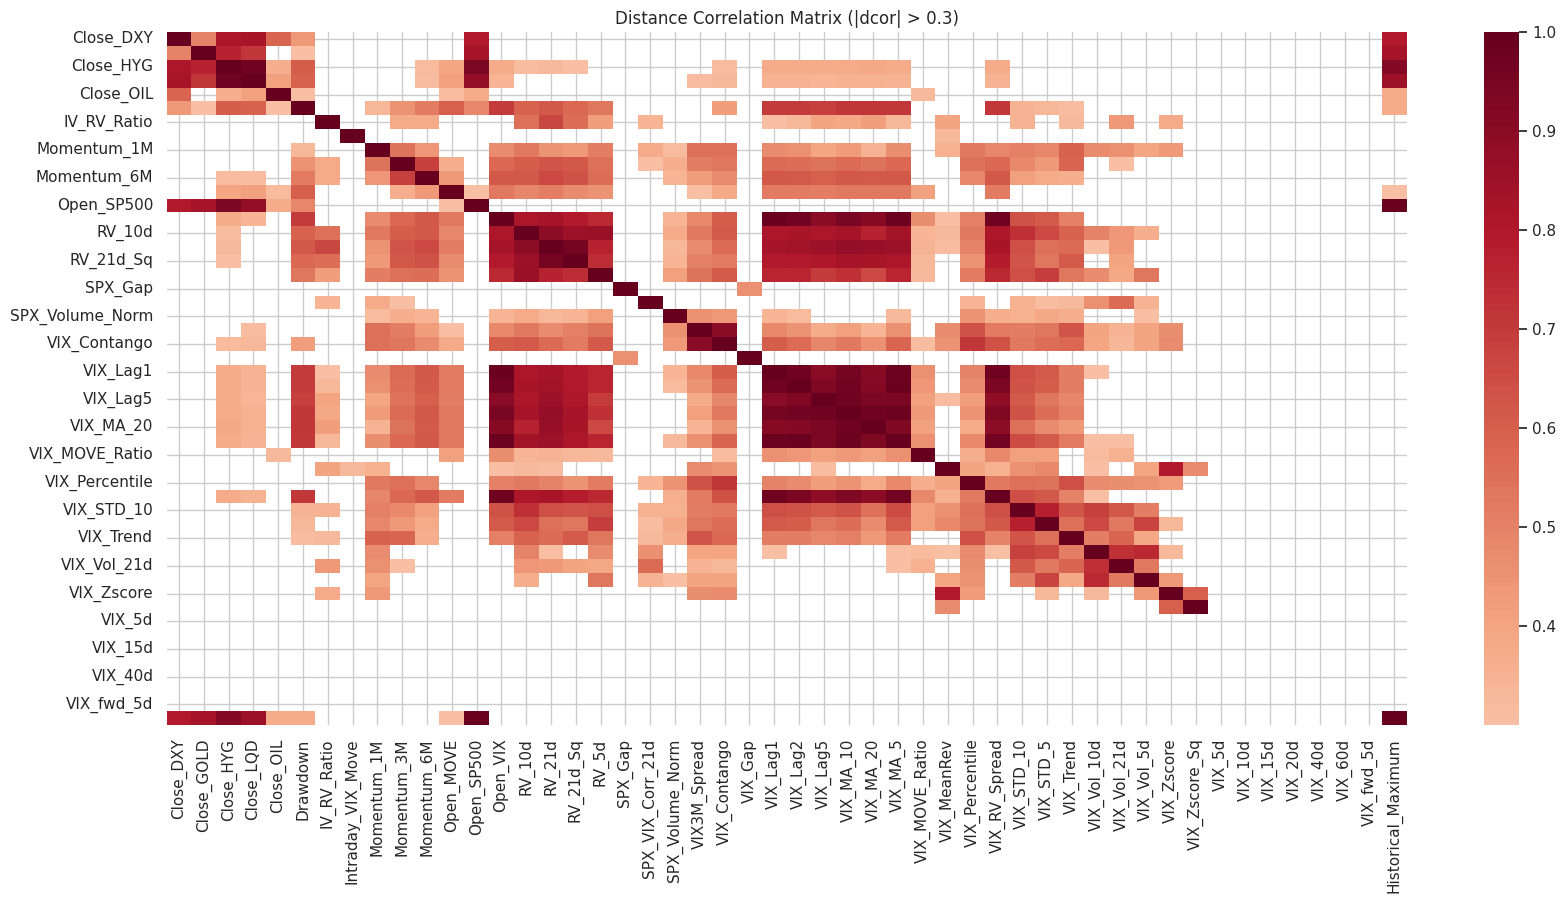

In [38]:
numeric_df = data_eda.select_dtypes(include=['number'])

cols = numeric_df.columns
n = len(cols)

# empty matrix
dcor_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols, index=cols)

# compute distance correlation (just numeric features)
for i in range(n):
    for j in range(i, n):
        x = numeric_df.iloc[:, i].values
        y = numeric_df.iloc[:, j].values

        val = dcor.distance_correlation(x, y)

        dcor_matrix.iloc[i, j] = val
        dcor_matrix.iloc[j, i] = val  # simetría

# filter low values
dcor_filtered = dcor_matrix.where(np.abs(dcor_matrix) > 0.3)

# plot
plt.figure(figsize=(20, 9))
sns.heatmap(dcor_filtered, cmap='RdBu_r', center=0)

plt.title("Distance Correlation Matrix (|dcor| > 0.3)")
plt.show()

## PCA

In [106]:
# select features that have at least one dcor > threshold with another feature
mask = dcor_filtered.any(axis=1)
selected_features = dcor_filtered.index[mask].drop('Open_VIX')

print("Features selected for PCA:", list(selected_features))

Features selected for PCA: ['Close_DXY', 'Close_GOLD', 'Close_HYG', 'Close_LQD', 'Close_OIL', 'Drawdown', 'IV_RV_Ratio', 'Intraday_VIX_Move', 'Momentum_1M', 'Momentum_3M', 'Momentum_6M', 'Open_MOVE', 'Open_SP500', 'RV_10d', 'RV_21d', 'RV_21d_Sq', 'RV_5d', 'SPX_Gap', 'SPX_VIX_Corr_21d', 'SPX_Volume_Norm', 'VIX3M_Spread', 'VIX_Contango', 'VIX_Gap', 'VIX_Lag1', 'VIX_Lag2', 'VIX_Lag5', 'VIX_MA_10', 'VIX_MA_20', 'VIX_MA_5', 'VIX_MOVE_Ratio', 'VIX_MeanRev', 'VIX_Percentile', 'VIX_RV_Spread', 'VIX_STD_10', 'VIX_STD_5', 'VIX_Trend', 'VIX_Vol_10d', 'VIX_Vol_21d', 'VIX_Vol_5d', 'VIX_Zscore', 'VIX_Zscore_Sq', 'Historical_Maximum']


In [107]:
X = numeric_df[selected_features].dropna()  # remove rows with NaN and target feature

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [112]:
# choose number of components (for example: 2)
pca = PCA(n_components=14)
X_pca = pca.fit(X_scaled)

# explained variance
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_,2))
print("Cumulative explained variance:", np.round(np.cumsum(pca.explained_variance_ratio_),2))
print("Dimensionality reduction", len(df.columns.drop("Open_VIX")), "->", 14, "|", round(14/len(df.columns.drop("Open_VIX"))*100,2), "%")

Explained variance ratio: [0.39 0.13 0.09 0.06 0.04 0.03 0.03 0.03 0.02 0.02 0.02 0.02 0.01 0.01]
Cumulative explained variance: [0.39 0.52 0.61 0.67 0.71 0.75 0.78 0.8  0.83 0.85 0.87 0.88 0.9  0.91]
Dimensionality reduction 41 -> 14 | 34.15 %


In [114]:
# PCA loadings (feature contribution to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("\nPCA Loadings:")
print(loadings)


PCA Loadings:
                         PC1       PC2       PC3       PC4       PC5  \
Close_DXY          -0.043010  0.308675 -0.174708 -0.082608 -0.078801   
Close_GOLD         -0.046945  0.291653 -0.165961 -0.136354 -0.103772   
Close_HYG          -0.098640  0.362612 -0.144999 -0.043124 -0.030054   
Close_LQD          -0.086767  0.350761 -0.152380 -0.020220  0.120401   
Close_OIL          -0.018505 -0.145293  0.106474 -0.055933 -0.393770   
Drawdown           -0.164300  0.203532  0.076161  0.180443 -0.021461   
IV_RV_Ratio        -0.103856  0.035744  0.158189 -0.301299  0.260251   
Intraday_VIX_Move  -0.003740  0.023569  0.133015 -0.211819  0.042590   
Momentum_1M        -0.147098 -0.089901 -0.163848 -0.037175  0.172988   
Momentum_3M        -0.175077 -0.005920 -0.001037 -0.008196  0.192588   
Momentum_6M        -0.170374  0.048144  0.033815  0.048032  0.155804   
Open_MOVE           0.142466 -0.091961 -0.092872 -0.225533 -0.378239   
Open_SP500         -0.066777  0.350324 -0.180555 

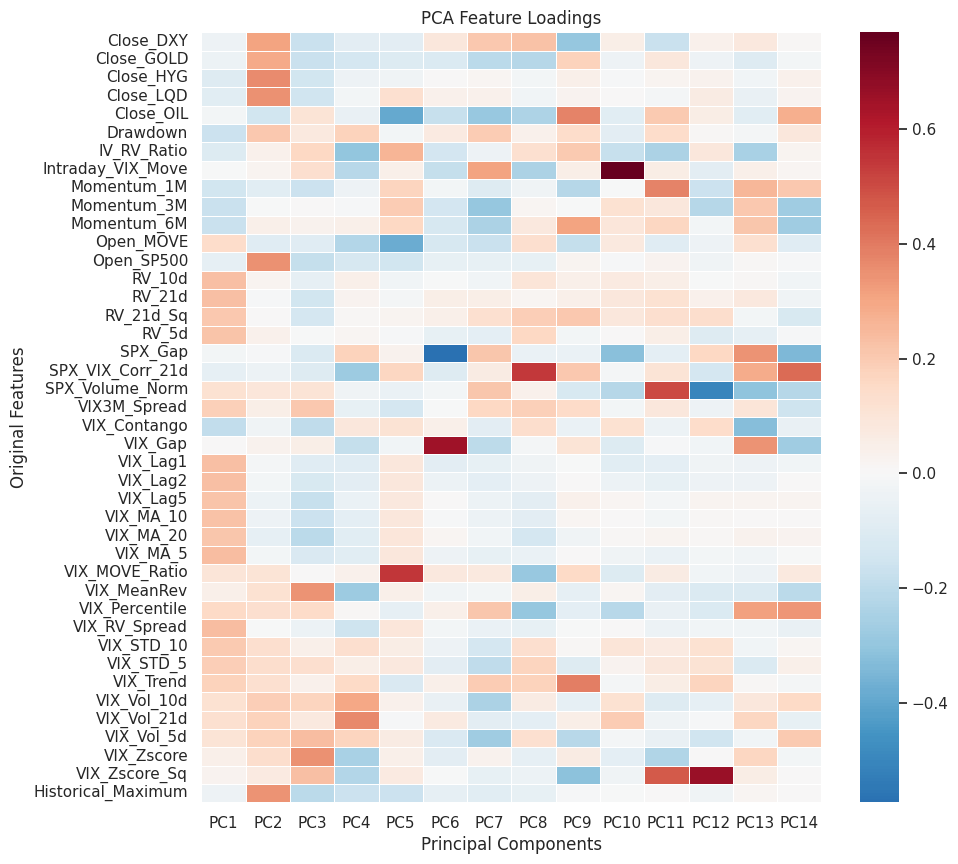

In [126]:
plt.figure(figsize=(10,10))
sns.heatmap(loadings, cmap='RdBu_r', center=0,linewidths=0.5)
plt.title("PCA Feature Loadings")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.show()